# Conformal Prediction for Classification: A High-Level Overview

This notebook extends the ideas from *01_conformal_tutorial.ipynb (regression)* to the
**classification** setting.

Given a desired miscoverage level $ \alpha \in (0,1) $, conformal classification methods
produce a **prediction set** $ \widehat{C}_\alpha(x) \subseteq \{1, \dots, K\} $ of plausible
labels that satisfies

$$
\mathbb{P}\left( Y_{n+1} \in \widehat{C}_\alpha(X_{n+1}) \right) \ge 1 - \alpha
$$

under the sole assumption that the data are **exchangeable** (e.g., i.i.d.).

Key ideas:
- Start with *any* classifier (neural network, tree ensemble, etc.)
- Define a **nonconformity score** that measures how poorly the model supports the true label
- Use a calibration set to choose a threshold on this score that guarantees coverage
- Include in the prediction set every label whose score does not exceed the threshold

Importantly, conformal prediction is **model-agnostic** and **distribution-free**: no
assumption is made on the classifier's accuracy or on the data distribution.

We illustrate these ideas on MNIST digit classification.


## Library Setup

This notebook requires the following Python packages:
- `numpy`: data manipulation
- `matplotlib`: plotting
- `torch`, `torchvision`: training the classifier and loading the MNIST dataset


In [1]:
# data manipulation and plotting
import matplotlib.pyplot as plt
import numpy as np

# neural network training
import torch
from torch import nn, optim
from torch.nn.functional import softmax
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import MNIST

## Dataset

We use the **MNIST** dataset of handwritten digits. Each input is a $28 \times 28$
grayscale image, and the label is the digit ($K = 10$ classes).


Train size: 60000
Test size: 10000


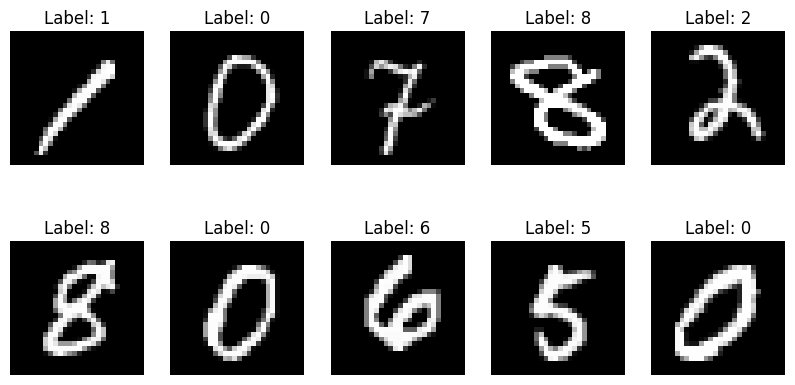

In [2]:
# Convert images to tensors (pixel values scaled to [0, 1])
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = MNIST(root="../../data", train=True, transform=transform, download=True)
test_dataset = MNIST(root="../../data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Visualize a handful of training images
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(0), cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")
plt.show()

## Base Classifier and Model-Agnosticism

As in the regression setting, conformal prediction is **model-agnostic**: it does not
require any particular classifier architecture, only that we can evaluate it on new inputs.

Here we use a small fully-connected network, `MnistClassifier`, with four hidden ReLU
layers and a final linear layer producing 10 raw outputs (**logits**), one per digit class.
Note that the network does **not** apply a softmax internally (it returns raw logits),
which will become important later in this notebook.


In [3]:
class MnistClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 8)
        self.fc2 = nn.Linear(8, 8)
        self.fc3 = nn.Linear(8, 8)
        self.fc4 = nn.Linear(8, 8)
        self.fc_out = nn.Linear(8, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        return self.fc_out(x)  # logits, no softmax


model = MnistClassifier()

## Training

The model is trained with `CrossEntropyLoss`, which internally applies a log-softmax
to the logits (the network itself still only ever returns logits).

Training is **not** re-run in this notebook; we load pretrained weights below instead. The
training routine is included for reference, with the calls to retrain and save the model
commented out.


In [4]:
def train_model(model, train_loader, num_epochs=500, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        if epoch % 10 == 0:
            avg_loss = running_loss / len(train_loader)
            print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

    return model


# model = train_model(model, train_loader, num_epochs=500, lr=0.001)
# torch.save(model.state_dict(), "mnist_classifier_500.pth")

We load the pretrained weights instead of retraining.


In [5]:
model = MnistClassifier()
model.load_state_dict(
    torch.load("../../data/mnist_classifier_500.pth", weights_only=True)
)
model.eval()


def get_accuracy(model, loader):
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            predicted = torch.argmax(outputs, axis=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total


print(f"Test accuracy: {get_accuracy(model, test_loader):.2f}%")

Test accuracy: 92.94%


## Calibration Split

As before, we set aside part of the test set for **calibration** and keep the rest for
evaluating empirical coverage.


In [6]:
calibration_size = 2000
calibration_dataset, eval_dataset = random_split(
    test_dataset, (calibration_size, len(test_dataset) - calibration_size)
)

calibration_loader = DataLoader(calibration_dataset, batch_size=64, shuffle=False)

all_logits = []
all_labels = []

with torch.no_grad():
    for images, labels in calibration_loader:
        all_logits.append(model(images))
        all_labels.append(labels)

all_logits = torch.cat(all_logits, dim=0)
all_labels = torch.cat(all_labels, dim=0)
all_softmax_probs = softmax(all_logits, dim=1)

## The Traditional Approach: Softmax Nonconformity Scores

The standard conformal classification approach (sometimes called LAC, the Least Ambiguous
set-valued Classifier) defines the nonconformity score of an example $(x, y)$ as

$$
s(x, y) = 1 - \widehat{\pi}_y(x),
$$

where $ \widehat{\pi}(x) = \mathrm{softmax}(\widehat{h}(x)) $ are the predicted class
probabilities and $ \widehat{\pi}_y(x) $ is the probability assigned to the true class $y$.
A low score means the model placed high probability on the correct label.

As in the regression notebook, the calibration quantile is

$$
\widehat{q}_{1-\alpha} = \mathrm{Quantile}_{1-\alpha}\left(s_1, \dots, s_{n_{\text{cal}}}\right),
$$

with the usual finite-sample correction.


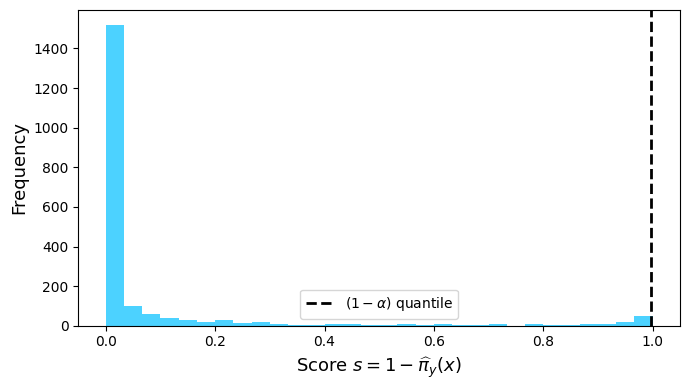

Softmax conformal quantile q_(1-alpha): 0.997


In [7]:
alpha = 0.01

softmax_scores = 1 - all_softmax_probs[torch.arange(all_labels.size(0)), all_labels]

n_cal = len(softmax_scores)
q_softmax = np.quantile(
    softmax_scores,
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
    method="higher",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(softmax_scores, bins=30, color="deepskyblue", alpha=0.7)
ax.axvline(
    q_softmax, color="black", linestyle="--", lw=2, label=r"$(1-\alpha)$ quantile"
)
ax.set_xlabel(r"Score $s = 1 - \widehat{\pi}_y(x)$", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Softmax conformal quantile q_(1-alpha): {q_softmax:.3f}")

## Constructing Prediction Sets

Given the quantile $ \widehat{q}_{1-\alpha} $, the conformal prediction set for a new input
$x$ includes every label $k$ whose nonconformity score does not exceed the threshold:

$$
\widehat{C}_\alpha(x) = \left\{ k : s(x, k) \le \widehat{q}_{1-\alpha} \right\}.
$$

We evaluate this on the held-out evaluation set and compare the **single most confident
prediction** (the usual `argmax` classifier) against the **conformal prediction set**, in
terms of how often each one covers the true label relative to the target $1 - \alpha$.

In the confusion-matrix plots below, the color scale is capped at 100 counts (`vmax=100`):
the diagonal entries (correct predictions) are far larger than the off-diagonal ones, so
without a cap they would dominate the color scale and the off-diagonal misclassifications
would all look the same shade.


In [8]:
def confusion_matrix(true_labels, pred_labels, n_classes=10):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(true_labels, pred_labels):
        cm[t, p] += 1
    return cm


def plot_confusion_matrices(cm_confident, cm_set, title_confident, title_set):
    vmax = 100  # cap the color scale so off-diagonal counts remain visible
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, cm, title in zip(
        axes, [cm_confident, cm_set], [title_confident, title_set]
    ):
        im = ax.imshow(cm, cmap="magma_r", vmin=0, vmax=vmax)
        ax.set_xlabel("Predicted Label")
        ax.set_ylabel("True Label")
        ax.set_title(title)
        ax.set_xticks(range(10))
        ax.set_yticks(range(10))
        for i in range(10):
            for j in range(10):
                # diagonal (correct) counts sit on a dark background, so they
                # need white text to stay legible
                color = "white" if i == j else "black"
                ax.text(
                    j, i, cm[i, j], ha="center", va="center", fontsize=7, color=color
                )
    fig.colorbar(im, ax=axes, shrink=0.8)
    plt.show()


def evaluate_prediction_sets(model, dataset, qhat, alpha, use_logits=False):
    true_labels, confident_preds, set_preds = [], [], []
    set_sizes, covered = [], []

    with torch.no_grad():
        for image, label in dataset:
            logits = model(image.unsqueeze(0))
            probs = softmax(logits, dim=1)
            confident_pred = int(torch.argmax(probs, dim=1))

            scores = -logits[0] if use_logits else 1 - probs[0]
            candidate_labels = torch.nonzero(scores <= qhat, as_tuple=True)[0]
            in_set = label in candidate_labels

            true_labels.append(label)
            confident_preds.append(confident_pred)
            set_sizes.append(max(1, len(candidate_labels)))
            covered.append(in_set)

            if in_set:
                set_preds.append(label)
            elif len(candidate_labels) > 0:
                set_preds.append(int(candidate_labels[0]))
            else:
                set_preds.append(confident_pred)

    true_labels = np.array(true_labels)
    confident_preds = np.array(confident_preds)
    set_preds = np.array(set_preds)

    cm_confident = confusion_matrix(true_labels, confident_preds)
    cm_set = confusion_matrix(true_labels, set_preds)

    accuracy = np.mean(true_labels == confident_preds)
    coverage = np.mean(covered)

    print(f"Single-prediction accuracy: {accuracy:.3f}")
    print(f"Average prediction set size: {np.mean(set_sizes):.3f}")
    print(f"Target coverage (1 - alpha): {1 - alpha:.2f}")
    print(f"Empirical conformal coverage: {coverage:.3f}")

    return cm_confident, cm_set

Single-prediction accuracy: 0.928
Average prediction set size: 1.956
Target coverage (1 - alpha): 0.99
Empirical conformal coverage: 0.991


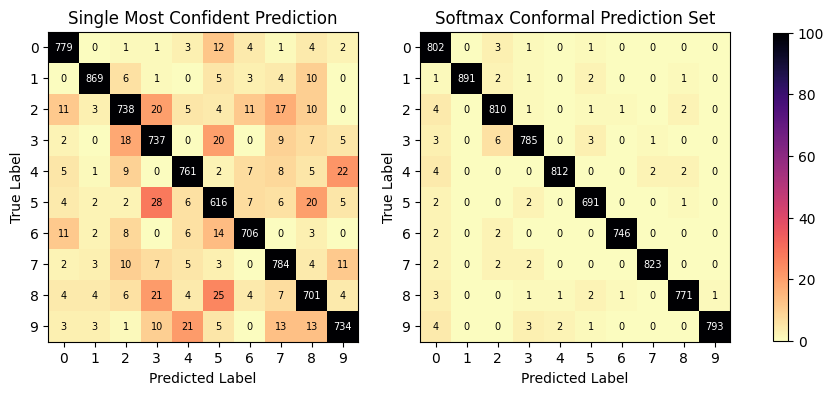

In [9]:
cm_confident, cm_set = evaluate_prediction_sets(
    model, eval_dataset, q_softmax, alpha, use_logits=False
)

plot_confusion_matrices(
    cm_confident,
    cm_set,
    "Single Most Confident Prediction",
    "Softmax Conformal Prediction Set",
)

## Operating Directly in Logit Space

The softmax-based score above is the standard choice in the conformal prediction
literature, but it has a drawback for our purposes: the softmax transformation

$$
\widehat{\pi}_k(x) = \frac{e^{\widehat{h}_k(x)}}{\sum_{j} e^{\widehat{h}_j(x)}}
$$

introduces an **extra nonlinearity** (an exponential and a division) on top of the network's
own activations. When the goal is to embed the classifier and its conformal guarantee
directly into a mixed-integer optimization model (as we do in Conformal Mixed-Integer
Constraint Learning, or C-MICL), every additional nonlinear transformation makes the
resulting formulation harder to encode exactly and more expensive to solve.

**This is one of the central modeling choices in our paper**: instead of calibrating on
softmax probabilities, we calibrate directly on the network's raw **logits**,

$$
s(x, y) = -\widehat{h}_y(x),
$$

so that a *more negative* score (a *larger* logit) means stronger support for label $y$.
Because $ \widehat{h}(x) $ is already piecewise-linear for a ReLU network, this score adds
**no extra nonlinearity** beyond what the network formulation already requires (the
conformal threshold becomes a simple linear constraint on the logits, with no softmax to
encode). We will use exactly this property in the next notebook, where the conformal
classifier is embedded into a Pyomo/OMLT optimization model.


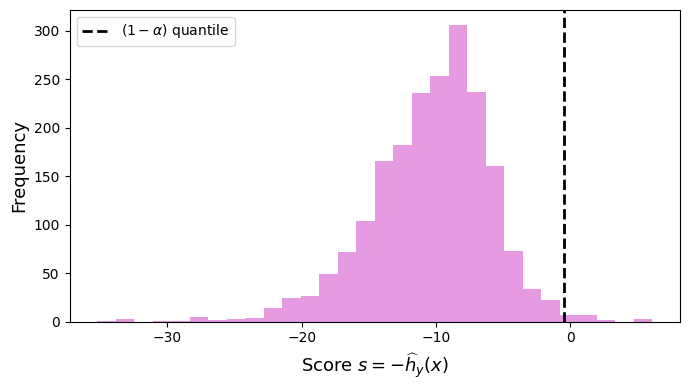

Logit conformal quantile q_(1-alpha): -0.458


In [10]:
logit_scores = -all_logits[torch.arange(all_labels.size(0)), all_labels]

q_logit = np.quantile(
    logit_scores,
    np.ceil((n_cal + 1) * (1 - alpha)) / n_cal,
    method="higher",
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(logit_scores, bins=30, color="orchid", alpha=0.7)
ax.axvline(q_logit, color="black", linestyle="--", lw=2, label=r"$(1-\alpha)$ quantile")
ax.set_xlabel(r"Score $s = -\widehat{h}_y(x)$", fontsize=13)
ax.set_ylabel("Frequency", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Logit conformal quantile q_(1-alpha): {q_logit:.3f}")

Single-prediction accuracy: 0.928
Average prediction set size: 3.690
Target coverage (1 - alpha): 0.99
Empirical conformal coverage: 0.991


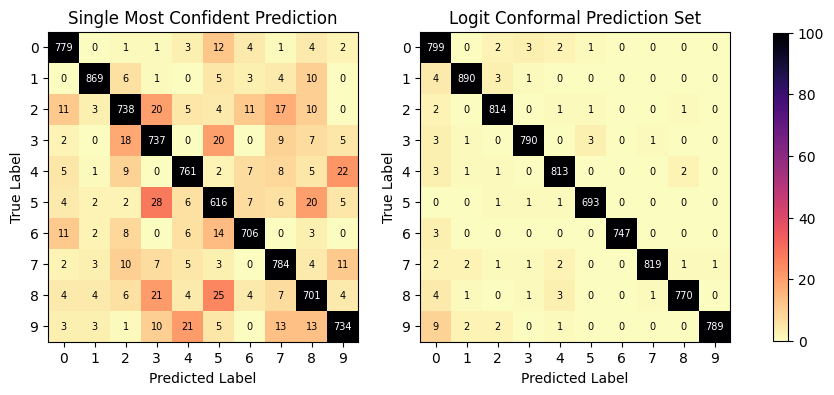

In [11]:
cm_confident, cm_set = evaluate_prediction_sets(
    model, eval_dataset, q_logit, alpha, use_logits=True
)

plot_confusion_matrices(
    cm_confident,
    cm_set,
    "Single Most Confident Prediction",
    "Logit Conformal Prediction Set",
)

## Discussion

In both cases, the conformal procedure achieves the desired coverage: the empirical
coverage on the held-out evaluation set matches the target $1 - \alpha$, whether the
nonconformity score is built from softmax probabilities or from raw logits. This is the
central guarantee of conformal prediction, it holds for any score function, as long as
the calibration and evaluation data are exchangeable.

The two scores do produce prediction sets of different average size in this example,
since logits are not normalized the way softmax probabilities are. What matters for our
purposes is that the logit-based score is defined directly in terms of the network's
natural piecewise-linear outputs, with no softmax to encode. This is exactly what we
exploit when embedding the conformal guarantee inside a mixed-integer optimization
formulation in the *02_uncertainty_integration.ipynb* notebook for classification.


## Citation

If this notebook was useful to your work, please cite:

```bibtex
@article{ovalle2026conformal,
  title={Conformal Mixed-Integer Constraint Learning with Feasibility Guarantees},
  author={Ovalle, Daniel and Biegler, Lorenz and Grossmann, Ignacio and Laird, Carl and Dulce Rubio, Mateo},
  journal={Advances in Neural Information Processing Systems},
  volume={38},
  pages={80387--80423},
  year={2026}
}
```
